#             **Project 1: Time Series & Category Charts**

# **IPL Time Series & Category Analysis**

##Syntecxhub Data Science Internship – Week 2


1.   IPL COMPLETE DATASET 2008–2025  
2.   Tools: Python · Pandas · Matplotlib · Seaborn
1.   Dataset Source: Kaggle – "IPL Complete Dataset 2008-2025 (Enhanced Edition)"
2.   Files Used   : matches.csv · deliveries.csv · seasons.csv · players.csv









######IMPORTS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

######LOAD DATA

In [6]:
matches    = pd.read_csv('/content/Data/matches.csv')
deliveries = pd.read_csv('/content/Data/deliveries.csv')
seasons    = pd.read_csv('/content/Data/seasons.csv')
players    = pd.read_csv('/content/Data/players.csv')

matches['date']  = pd.to_datetime(matches['date'])
matches['month'] = matches['date'].dt.month

print("Dataset shapes:")
print(f"  matches    : {matches.shape}")
print(f"  deliveries : {deliveries.shape}")
print(f"  seasons    : {seasons.shape}")
print(f"  players    : {players.shape}")

Dataset shapes:
  matches    : (1158, 26)
  deliveries : (134190, 18)
  seasons    : (18, 14)
  players    : (580, 12)


######GLOBAL STYLING

In [7]:
PALETTE = ['#4361ee','#3a0ca3','#7209b7','#f72585','#4cc9f0',
           '#06d6a0','#ffd166','#ef476f','#118ab2','#073b4c']
BG     = '#f8f9fa'
ACCENT = '#4361ee'
DARK   = '#212529'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'axes.facecolor'     : BG,
    'figure.facecolor'   : 'white',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.labelsize'     : 11,
    'axes.titlesize'     : 13,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'axes.titleweight'   : 'bold',
})

###### CHART 1 ─ Total Runs Scored Per Season  (Time Series Line Chart)
###### WHY: A line chart is ideal for showing trends over continuous time.
######      Filled area below the line emphasizes growth/variation in run volume.


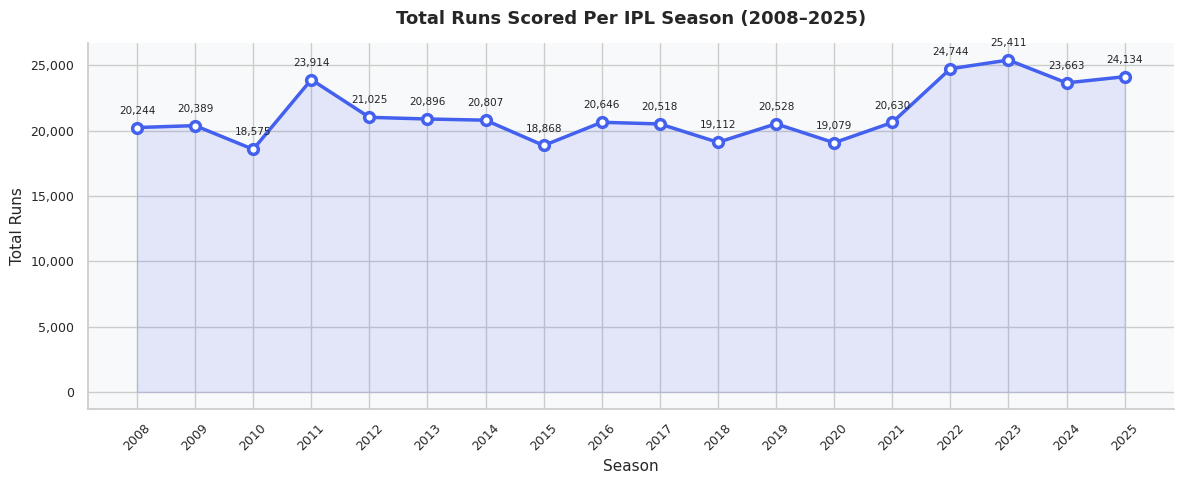

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(seasons['season'], seasons['total_runs_scored'],
        marker='o', linewidth=2.5, color=ACCENT, markersize=7,
        markerfacecolor='white', markeredgewidth=2.5)

for _, row in seasons.iterrows():
    ax.annotate(f"{int(row['total_runs_scored']):,}",
                xy=(row['season'], row['total_runs_scored']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, color=DARK)

ax.fill_between(seasons['season'], seasons['total_runs_scored'],
                alpha=0.12, color=ACCENT)
ax.set_title('Total Runs Scored Per IPL Season (2008–2025)', pad=14)
ax.set_xlabel('Season')
ax.set_ylabel('Total Runs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(seasons['season'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_runs_per_season.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 2 ─ Avg First Innings Score & Total Sixes  (Dual-Axis Line)
###### WHY: Two metrics with different scales share a time axis.
######       Dual-axis prevents one metric from dominating the visual.


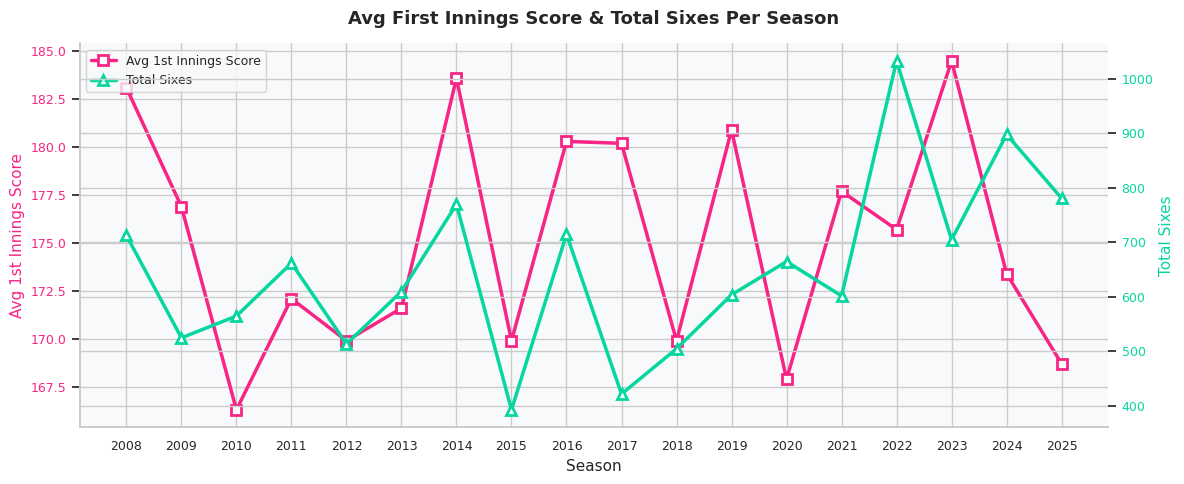

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(seasons['season'], seasons['avg_first_innings_score'],
         marker='s', color='#f72585', linewidth=2.5, markersize=7,
         markerfacecolor='white', markeredgewidth=2, label='Avg 1st Innings Score')
ax2.plot(seasons['season'], seasons['total_sixes'],
         marker='^', color='#06d6a0', linewidth=2.5, markersize=7,
         markerfacecolor='white', markeredgewidth=2, label='Total Sixes')

ax1.set_xlabel('Season')
ax1.set_ylabel('Avg 1st Innings Score', color='#f72585')
ax2.set_ylabel('Total Sixes', color='#06d6a0')
ax1.tick_params(axis='y', labelcolor='#f72585')
ax2.tick_params(axis='y', labelcolor='#06d6a0')
ax1.set_xticks(seasons['season'])
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Avg First Innings Score & Total Sixes Per Season', pad=14)
plt.tight_layout()
plt.savefig('chart2_score_sixes_trend.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 3 ─ Top 10 Teams by Total Wins  (Horizontal Bar Chart)
###### WHY: Horizontal bars are ideal for labeled categorical comparisons.
######      Sorted order makes ranking immediately readable.


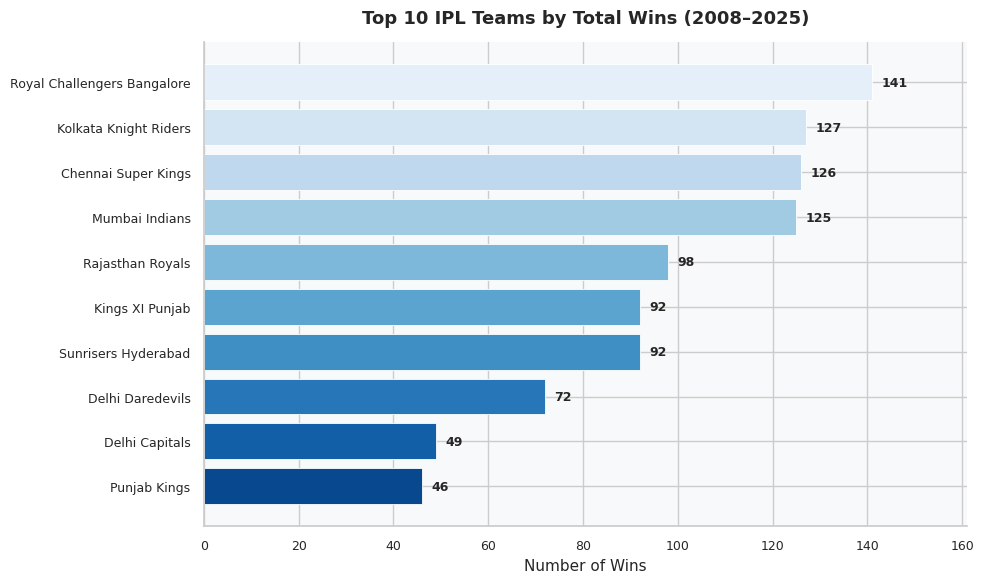

In [10]:
wins = matches[matches['result'] == 'normal']['winner'].value_counts().head(10)
colors_bar = sns.color_palette('Blues_r', len(wins))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(wins.index[::-1], wins.values[::-1],
               color=colors_bar, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, wins.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_title('Top 10 IPL Teams by Total Wins (2008–2025)', pad=14)
ax.set_xlabel('Number of Wins')
ax.set_xlim(0, wins.values.max() + 20)
plt.tight_layout()
plt.savefig('chart3_team_wins_bar.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 4 ─ Toss Decision Share  (Pie Chart)
###### WHY: Pie charts excel at showing proportional share of a whole.
######     Two categories (bat/field) are perfect for a pie.


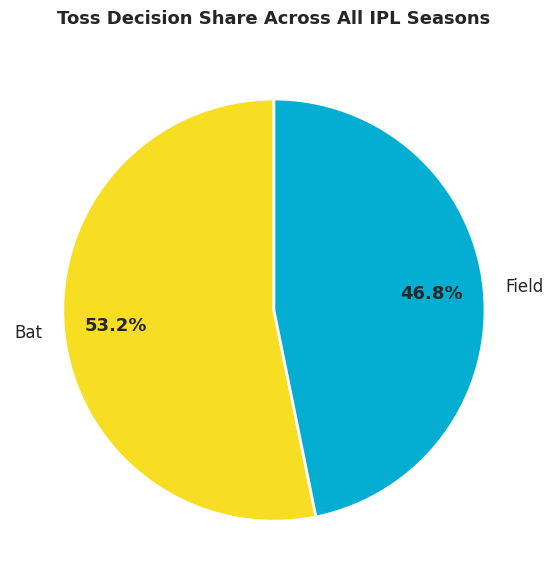

In [13]:
toss = matches['toss_decision'].value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    toss.values,
    labels=toss.index.str.capitalize(),
    autopct='%1.1f%%',
    colors=['#F8DE22', '#03AED2'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
ax.set_title('Toss Decision Share Across All IPL Seasons', pad=16)
plt.tight_layout()
plt.savefig('chart4_toss_decision_pie.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 5 ─ Matches Per Month  (Bar Chart – Monthly Aggregation)
###### WHY: Bar charts reveal categorical distribution clearly.
######      Month aggregation shows IPL's typical scheduling pattern.


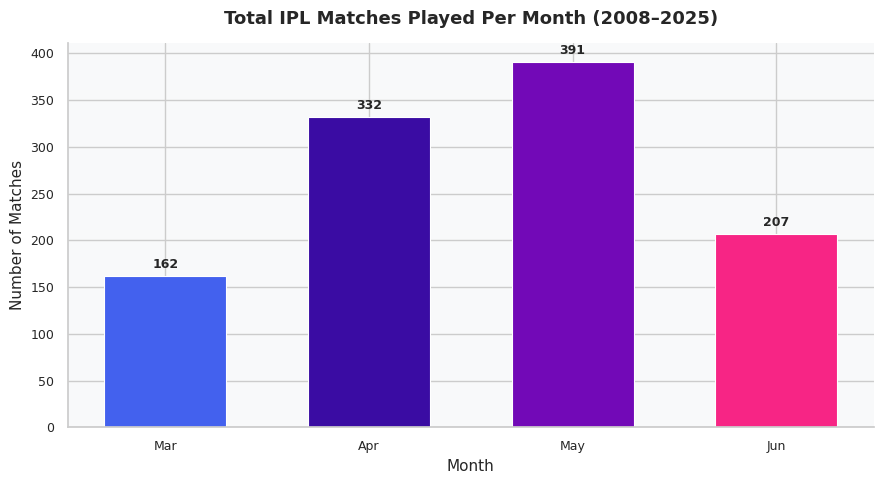

In [19]:
month_map = {3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 10:'Oct', 11:'Nov'}
monthly = matches.groupby('month').size().reset_index(name='count')
monthly = monthly[monthly['month'].isin(month_map.keys())].copy()
monthly['month_name'] = monthly['month'].map(month_map)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(monthly['month_name'], monthly['count'],
              color=PALETTE[:len(monthly)], edgecolor='white',
              linewidth=0.8, width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_title('Total IPL Matches Played Per Month (2008–2025)', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Matches')
plt.tight_layout()
plt.savefig('chart5_matches_per_month.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 6 ─ Sixes vs Fours Per Season  (Grouped Bar)
###### WHY: Grouped bars allow direct season-by-season comparison of two metrics.
######      Shows how the game's aggression has evolved over time.


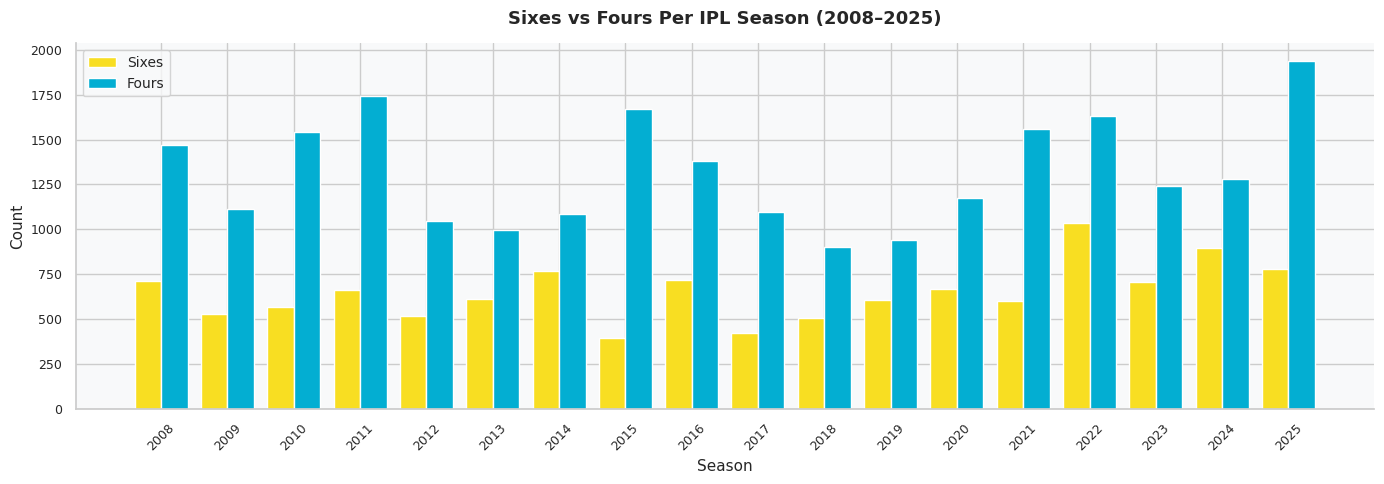

In [21]:
x = np.arange(len(seasons))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, seasons['total_sixes'],  width, label='Sixes',
       color='#F8DE22', edgecolor='white')
ax.bar(x + width/2, seasons['total_fours'],  width, label='Fours',
       color='#03AED2', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(seasons['season'], rotation=45)
ax.set_title('Sixes vs Fours Per IPL Season (2008–2025)', pad=14)
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart6_sixes_fours_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 7 ─ Win Method Share  (Pie Chart)
###### WHY: Proportion between runs/wickets victories is a categorical split.
######      Pie chart communicates the share at a glance.


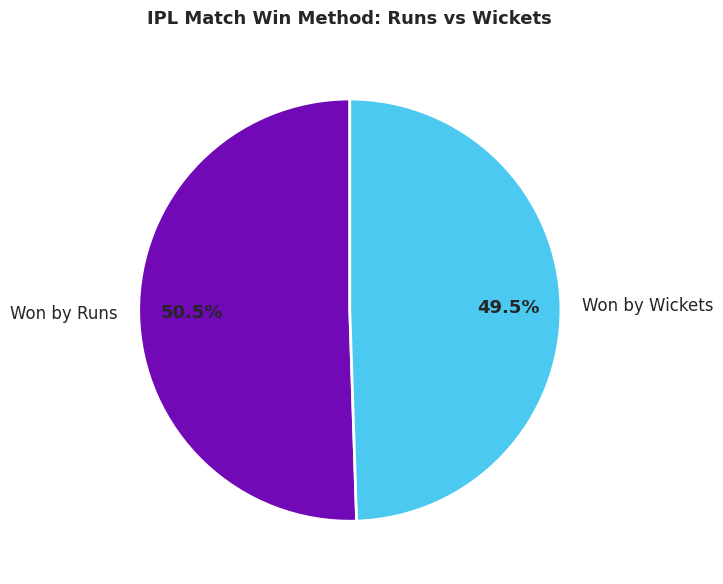

In [22]:
by_runs    = matches[(matches['result']=='normal') & (matches['win_by']=='runs')].shape[0]
by_wickets = matches[(matches['result']=='normal') & (matches['win_by']=='wickets')].shape[0]

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    [by_runs, by_wickets],
    labels=['Won by Runs', 'Won by Wickets'],
    autopct='%1.1f%%',
    colors=['#7209b7', '#4cc9f0'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
ax.set_title('IPL Match Win Method: Runs vs Wickets', pad=16)
plt.tight_layout()
plt.savefig('chart7_win_method_pie.png', dpi=150, bbox_inches='tight')
plt.show()


###### CHART 8 ─ IPL Title Count by Team  (Horizontal Bar)
###### WHY: Champions are sparse (≤5 unique winners), making a ranked bar
######      the clearest way to show dominance hierarchy.


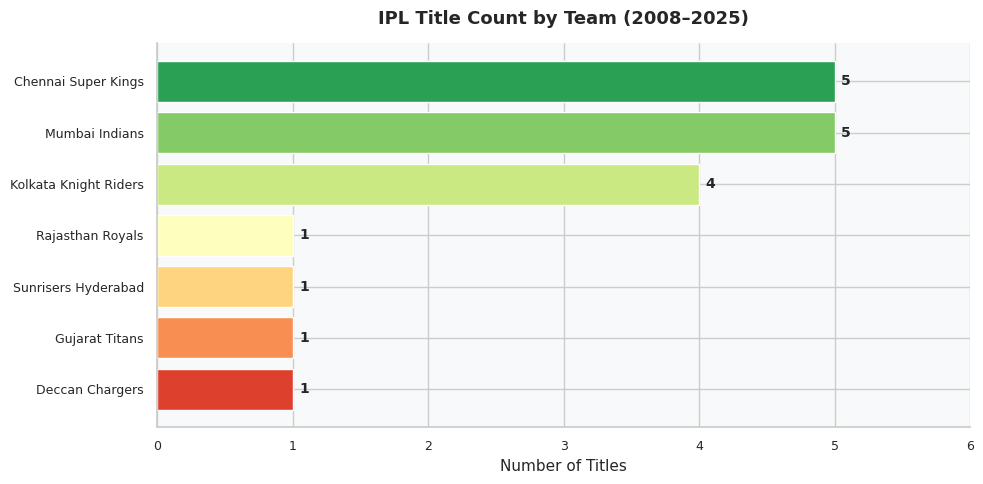

In [23]:
champ_counts = seasons['champion'].value_counts().reset_index()
champ_counts.columns = ['team', 'titles']
champ_counts = champ_counts.sort_values('titles', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_c = sns.color_palette('RdYlGn', len(champ_counts))
bars = ax.barh(champ_counts['team'], champ_counts['titles'],
               color=colors_c, edgecolor='white')
for bar, val in zip(bars, champ_counts['titles']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left',
            fontsize=10, fontweight='bold')
ax.set_title('IPL Title Count by Team (2008–2025)', pad=14)
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, champ_counts['titles'].max() + 1)
plt.tight_layout()
plt.savefig('chart8_ipl_champions.png', dpi=150, bbox_inches='tight')
plt.show()
